# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:** 

Переменная $x \in \mathbb{R}^3$ — искомая точка на прямой, $p = (1,2,3)^\top$. 

Расстояние и квадрат расстояния минимальны в одной и той же точке, но квадрат гладкий, поэтому минимизируем квадрат:

$$\min_{x \in \mathbb{R}^3} \; f(x) = \tfrac12\|x - p\|^2 \quad\text{при}\quad g(x) = \begin{pmatrix} x_1 + x_2 + x_3 - 1 \\ x_1 - x_3 \end{pmatrix} = 0.$$

Класс задачи: QP с ограничениями-равенствами, выпуклая ($\nabla^2 f = I \succ 0$).

In [2]:
p = np.array([1.0, 2.0, 3.0])
G = np.array([[1.0, 1.0, 1.0], [1.0, 0.0, -1.0]])
res = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), np.zeros(3),
               constraints=[{"type": "eq", "fun": lambda x: G @ x - np.array([1.0, 0.0])}])
print("x* =", np.round(res.x, 6))

x* = [0.333333 0.333333 0.333333]


**(б)**

**Ответ:**

Переменная $x \in \mathbb{R}^n$ — количества продуктов:

$$\min_{x \in \mathbb{R}^n} \; f(x) = c^\top x \quad\text{при}\quad h(x) = \begin{pmatrix} Ax - b \\ x \end{pmatrix} \ge 0 .$$

Первые $m$ компонент $h$ — нормы по веществам, последние $n$ — неотрицательность покупок.

Класс задачи: LP с ограничениями-неравенствами, выпуклая (все функции линейны).

**(в)**

**Ответ:**

Диагонали вписанного прямоугольника — диаметры, значит центр совпадает с центром круга, вершины — $(\pm u, \pm v)$.

Переменная $x = (u, v)^\top \in \mathbb{R}^2$ — половины сторон, площадь $4uv$:

$$\min_{u, v} \; f(u,v) = -4uv \quad\text{при}\quad g(u,v) = u^2 + v^2 - 1 = 0, \qquad h(u,v) = \begin{pmatrix} u \\ v \end{pmatrix} \ge 0 .$$

Класс задачи: QCQP с ограничениями, невыпуклая.

Невыпуклость: окружность $g = 0$ — невыпуклое множество; у $\nabla^2 f = \left(\begin{smallmatrix} 0 & -4 \\ -4 & 0\end{smallmatrix}\right)$ собственные числа $\pm 4$, то есть и $f$ невыпукла.

**(г)**

**Ответ:**

Переменная $x = (x_1, x_2, x_3)^\top \in \mathbb{R}^3$ — амплитуда, частота, фаза:

$$\min_{x \in \mathbb{R}^3} \; f(x) = \tfrac12 \sum_{i=1}^N \big(x_1 \sin(x_2 t_i + x_3) - y_i\big)^2.$$

Класс задачи: безусловная NLP (нелинейный МНК), невыпуклая. Модель нелинейна по $x_2$ и $x_3$, целевая функция не квадратична.

Невыпуклость: $f$ не меняется при замене $(x_1, x_3) \mapsto (-x_1, x_3 + \pi)$, то есть минимум не единственный. В середине двух таких минимумов $x_1 = 0$, модель нулевая, и это не минимум. Множество минимумов невыпукло, у выпуклой функции так не бывает.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

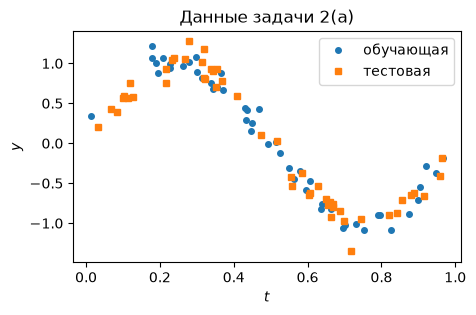

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

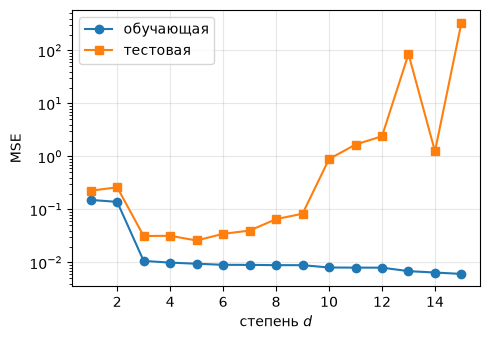

минимум на тесте: d = 5


In [4]:
degrees = np.arange(1, 16)
mse_train, mse_test = [], []

for d in degrees:
    A_tr = np.vander(t_train, d + 1, increasing=True)
    x_hat, *_ = np.linalg.lstsq(A_tr, y_train, rcond=None)
    mse_train.append(np.mean((A_tr @ x_hat - y_train) ** 2))
    mse_test.append(np.mean((np.vander(t_test, d + 1, increasing=True) @ x_hat - y_test) ** 2))

plt.figure(figsize=(5, 3.5))
plt.semilogy(degrees, mse_train, "o-", label="обучающая")
plt.semilogy(degrees, mse_test, "s-", label="тестовая")
plt.xlabel("степень $d$"); plt.ylabel("MSE"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("минимум на тесте: d =", degrees[np.argmin(mse_test)])

**Ответ:**

Обучающая кривая монотонно убывает: полином степени $d$ — частный случай полинома степени $d+1$, а минимум по большему множеству не больше.

Тестовая до $d = 5$ падает, затем растёт: лишние степени свободы подгоняются под шум обучающей выборки, а в тестовой шум другой.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
def solve(b):
    res = linprog(c, A_ub=-A, b_ub=-b, bounds=(0, None))   # Ax >= b  <=>  -Ax <= -b
    print("x* =", np.round(res.x, 6), " стоимость =", round(res.fun, 6))
    print("активны Ax >= b:", [i + 1 for i in range(len(b)) if abs((A @ res.x - b)[i]) <= 1e-9],
          " активны x >= 0:", [j + 1 for j in range(len(res.x)) if abs(res.x[j]) <= 1e-9])
    return res

print("исходная задача")
r1 = solve(b)
print("\nb1 -> b1 + 1")
r2 = solve(b + np.array([1.0, 0.0, 0.0]))
print("\nизменение стоимости:", round(r2.fun - r1.fun, 6))

исходная задача
x* = [ 2.  4. -0.  0.]  стоимость = 16.0
активны Ax >= b: [1, 2, 3]  активны x >= 0: [3, 4]

b1 -> b1 + 1
x* = [1.888889 3.555556 0.       0.666667]  стоимость = 17.111111
активны Ax >= b: [1, 2, 3]  активны x >= 0: [3]

изменение стоимости: 1.111111


**Ответ:**

Исходная задача: $x^\ast = (2, 4, 0, 0)^\top$, стоимость 16. Активны все три ограничения $Ax \ge b$ (запаса по веществам нет) и два ограничения $x \ge 0$: продукты 3 и 4 не покупаются.

При $b_1 = 11$: $x^\ast \approx (1.889,\, 3.556,\, 0,\, 0.667)^\top$, стоимость $\approx 17.111$, на $1.111$ больше. Продуктов 1 и 2 меньше, добавился продукт 4 — кроме них он единственный с веществом 1.

Набор активных $Ax \ge b$ не изменился, набор активных $x \ge 0$ изменился: ушло $x_4 \ge 0$, осталось $x_3 \ge 0$.